In [1]:
# ============================================================
# CELL 1 — Installs + Imports + All Paths
# ============================================================
#
# WHAT THIS NOTEBOOK DOES:
#   Merged Notebook 3 + Notebook 4.
#   Takes raw BMC images through the complete pipeline:
#
#   Step 1: Verify image is a BMC (Notebook 1 YOLO verifier)
#   Step 2: Detect and crop 9 sections (Notebook 1 YOLO detector)
#   Step 3: Classify each crop — typed or handwritten (Notebook 2 CNN)
#   Step 4a: Typed crops → EasyOCR → text
#   Step 4b: Handwritten crops → LLaVA-1.5-7B VLM → text description
#   Step 5: RAG — retrieve relevant BMC book passages
#   Step 6: Fine-tuned Llama 3.2-3B evaluates each section
#   Step 7: Coherence check, SDG advice, overall score, feedback
#   Step 8: Save full evaluation report (JSON + CSV)
#
# ACADEMIC REQUIREMENTS COVERED:
#   Computer Vision (pretrained): Notebook 1 YOLO ✅
#   Deep Learning from scratch:   Notebook 2 CNN  ✅
#   XAI:                          GradCAM in NB2  ✅
#   LLM fine-tuning:              Llama 3.2-3B QLoRA ✅
#   VLM:                          LLaVA-1.5-7B ✅
#   RAG:                          FAISS + BMC book ✅
#   SDG / Zero Carbon:            LLM evaluation prompt ✅

!pip install ultralytics easyocr transformers peft accelerate \
             bitsandbytes sentence-transformers faiss-cpu \
             PyMuPDF datasets trl pillow opencv-python-headless \
             torch torchvision pandas tqdm --quiet

import os
import re
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageOps, ImageFilter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

import fitz  # PyMuPDF — PDF reading
import easyocr
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    TrOCRProcessor, VisionEncoderDecoderModel,
)
from peft import PeftModel, LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
import faiss

# ══════════════════════════════════════════════════════════
# ← CHANGE THESE PATHS TO YOUR ACTUAL KAGGLE DATASET NAMES
# ══════════════════════════════════════════════════════════


from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

print("Token loaded:", HF_TOKEN[:10])  # debug


# Notebook 1 models — YOLOv8 verifier + detector
NB1_MODELS_PATH = Path("/kaggle/input/datasets/ghofranegharbi/bmc-botebook1-models/not1_models")
# Expected files inside:
#   bmc_verifier.pt   ← YOLOv8 classification model
#   bmc_detector.pt   ← YOLOv8 detection model

# Notebook 2 model — CNN classifier
NB2_MODEL_PATH = Path("/kaggle/input/datasets/ghofranegharbi/bmc-not2-model/bmc_text_cnn_best.pt")
# Single .pt file with model_state_dict, val_loss, val_acc

# BMC book PDF for RAG
BMC_BOOK_PATH = Path("/kaggle/input/datasets/ghofranegharbi/bmc-book/")
# Expected: one PDF file inside this folder

# HuggingFace token — needed for Llama 3.2-3B and LLaVA-1.5-7B
# Add as Kaggle Secret named HF_TOKEN:
#   Kaggle notebook → Settings → Environment variables → Add secret
#HF_TOKEN = os.environ.get("HF_TOKEN", "")

# Fine-tuned Llama adapter — output of QLoRA fine-tuning in this notebook
# If running fine-tuning for the first time, this will be created.
# If you already fine-tuned and saved, point here to skip retraining.
LLAMA_ADAPTER_PATH = Path("/kaggle/working/llama_bmc_adapter")
# Set to None to force retraining: LLAMA_ADAPTER_PATH = None

# ══════════════════════════════════════════════════════════

# Working directories
WORK_DIR   = Path("/kaggle/working")
OUTPUT_DIR = WORK_DIR / "final_evaluations"
JSON_DIR   = OUTPUT_DIR / "json"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Constants
CLASS_NAMES = [
    'KeyPartners', 'KeyActivities', 'ValuePropositions',
    'CustomerRelationships', 'CustomerSegments',
    'KeyResources', 'Channels', 'CostStructure', 'RevenueStreams'
]

SECTION_DISPLAY = {
    'KeyPartners':           'Key Partners',
    'KeyActivities':         'Key Activities',
    'ValuePropositions':     'Value Propositions',
    'CustomerRelationships': 'Customer Relationships',
    'CustomerSegments':      'Customer Segments',
    'KeyResources':          'Key Resources',
    'Channels':              'Channels',
    'CostStructure':         'Cost Structure',
    'RevenueStreams':         'Revenue Streams',
}

CNN_CONFIDENCE_THRESHOLD = 0.70

# Validate critical paths
for p, label in [
    (NB1_MODELS_PATH, "NB1 models"),
    (NB2_MODEL_PATH,  "NB2 model"),
    (BMC_BOOK_PATH,   "BMC book"),
]:
    status = "✅" if p.exists() else "❌ NOT FOUND"
    print(f"{label:<20}: {status} — {p}")

if not HF_TOKEN:
    print("⚠️  HF_TOKEN not set — needed for Llama + LLaVA")
    print("   Add it: Kaggle → Settings → Secrets → HF_TOKEN")
else:
    print("HF_TOKEN            : ✅ found")

print("\nSetup complete ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 34.5 MB/s eta 0:00:00
Token loaded: hf_ZxTULTc
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
NB1 models          : ✅ — /kaggle/input/datasets/ghofranegharbi/bmc-botebook1-models/not1_models
NB2 model           : ✅ — /kaggle/input/datasets/ghofranegharbi/bmc-not2-model/bmc_text_cnn_best.pt
BMC book            : ✅ — /kaggle/input/datasets/ghofranegharbi/bmc-book
HF_TOKEN            : ✅ found

Setup complete ✅


In [2]:

# ============================================================
# CELL 2 — Load Notebook 1 Models (YOLO Verifier + Detector)
# ============================================================
#
# WHAT THIS CELL DOES:
#   Loads both YOLO models from Notebook 1.
#   These are the pretrained computer vision models.
#
# VERIFIER:  YOLOv8 classification — answers "Is this a BMC?"
# DETECTOR:  YOLOv8 detection — finds and labels 9 section boxes
#
# Both models were fine-tuned on BMC data in Notebook 1.
# We use them here as frozen inference models — no retraining.

from ultralytics import YOLO

# ── Find model files ──────────────────────────────────────
def find_yolo_model(folder: Path, keywords: list) -> Path:
    """
    Search folder for a YOLO model file matching any keyword.
    Returns the first match found.
    """
    for f in folder.glob("*.pt"):
        if any(kw in f.name.lower() for kw in keywords):
            return f
    # Fallback: return first .pt file found
    all_pts = list(folder.glob("*.pt"))
    if all_pts:
        return all_pts[0]
    raise FileNotFoundError(
        f"No .pt file found in {folder}\n"
        f"Expected keywords: {keywords}"
    )

verifier_file = find_yolo_model(NB1_MODELS_PATH, ['verif', 'cls', 'classification'])
detector_file = find_yolo_model(NB1_MODELS_PATH, ['detect', 'bmc_det'])

print(f"Verifier model : {verifier_file.name}")
print(f"Detector model : {detector_file.name}")

yolo_verifier = YOLO(str(verifier_file))
yolo_detector = YOLO(str(detector_file))

print("YOLO models loaded ✅")

yolo_device = '0' if torch.cuda.is_available() else 'cpu'


def verify_bmc(img_path: str) -> tuple:
    """
    Run YOLO verifier on image.
    Returns (is_bmc: bool, bmc_confidence: float, not_bmc_confidence: float)
    """
    result      = yolo_verifier.predict(img_path, device=yolo_device, verbose=False)
    pred_cls    = result[0].probs.top1
    bmc_conf    = float(result[0].probs.data[0])
    not_bmc_conf = float(result[0].probs.data[1])
    is_bmc      = (pred_cls == 0)
    return is_bmc, bmc_conf, not_bmc_conf


def detect_sections(img_path: str) -> list:
    """
    Run YOLO detector on a confirmed BMC image.
    Returns list of dicts:
        class_id, class_name, confidence, x1, y1, x2, y2
    """
    result = yolo_detector.predict(
        img_path, device=yolo_device, conf=0.25, verbose=False
    )
    boxes  = result[0].boxes
    if boxes is None or len(boxes) == 0:
        return []

    detections = []
    for box in boxes:
        cls_id = int(box.cls)
        detections.append({
            'class_id':   cls_id,
            'class_name': CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f'class_{cls_id}',
            'confidence': float(box.conf),
            'x1': int(box.xyxy[0][0]),
            'y1': int(box.xyxy[0][1]),
            'x2': int(box.xyxy[0][2]),
            'y2': int(box.xyxy[0][3]),
        })
    return detections


def crop_sections(img_cv, detections: list, pad: int = 5) -> dict:
    """
    Crop each detected section from the image.
    Returns dict: {section_name: PIL_Image}
    """
    h, w   = img_cv.shape[:2]
    crops  = {}
    for det in detections:
        name = det['class_name']
        x1c  = max(0, det['x1'] - pad)
        y1c  = max(0, det['y1'] - pad)
        x2c  = min(w, det['x2'] + pad)
        y2c  = min(h, det['y2'] + pad)
        crop = img_cv[y1c:y2c, x1c:x2c]
        if crop.size > 0:
            crops[name] = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    return crops


# ── Quick test ────────────────────────────────────────────
print("\nNB1 pipeline functions ready:")
print("  verify_bmc(img_path)    → (is_bmc, bmc_conf, not_bmc_conf)")
print("  detect_sections(img)    → list of detection dicts")
print("  crop_sections(img, det) → {section_name: PIL_Image}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Verifier model : bmc_verifier.pt
Detector model : bmc_detector.pt
YOLO models loaded ✅

NB1 pipeline functions ready:
  verify_bmc(img_path)    → (is_bmc, bmc_conf, not_bmc_conf)
  detect_sections(img)    → list of detection dicts
  crop_sections(img, det) → {section_name: PIL_Image}


In [3]:
# ============================================================
# CELL 3 — Load Notebook 2 LSTM Classifier
# ============================================================
#
# FIX: Notebook 2 was updated to BMCTextLSTM (row-patch LSTM).
# The checkpoint contains LSTM weights, not CNN weights.
# This cell replaces BMCTextCNN with BMCTextLSTM to match.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageOps
import numpy as np
import cv2

# ── Dimensions (must match Notebook 2 Cell 4 exactly) ───────
IMG_SIZE  = 224
N_PATCHES = 16
PATCH_H   = IMG_SIZE // N_PATCHES    # 14
PATCH_DIM = IMG_SIZE * PATCH_H * 3  # 9408


# ── Architecture (identical to Notebook 2) ──────────────────

class PatchEmbedding(nn.Module):
    def __init__(self, patch_dim: int, embed_dim: int, dropout: float = 0.2):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(patch_dim, embed_dim, bias=False),
            nn.LayerNorm(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.proj(x)


class AttentionPooling(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size, bias=True)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out: torch.Tensor):
        scores  = self.v(torch.tanh(self.W(lstm_out)))
        weights = F.softmax(scores.squeeze(-1), dim=1)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)
        return context, weights


class BMCTextLSTM(nn.Module):
    def __init__(self,
                 patch_dim:   int   = PATCH_DIM,
                 embed_dim:   int   = 256,
                 hidden_size: int   = 256,
                 num_layers:  int   = 2,
                 num_classes: int   = 2,
                 dropout:     float = 0.3):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_dim, embed_dim, dropout=0.2)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False,
        )
        self.attention  = AttentionPooling(hidden_size)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, patches: torch.Tensor):
        embedded         = self.patch_embed(patches)
        lstm_out, _      = self.lstm(embedded)
        context, weights = self.attention(lstm_out)
        return self.classifier(context), weights


# ── Load weights ─────────────────────────────────────────────
checkpoint = torch.load(str(NB2_MODEL_PATH), map_location=device)

# Read config saved alongside weights — falls back to defaults
saved_patch_dim   = checkpoint.get('patch_dim',   PATCH_DIM)
saved_embed_dim   = checkpoint.get('embed_dim',   256)
saved_hidden_size = checkpoint.get('hidden_size', 256)

cnn_model = BMCTextLSTM(
    patch_dim=saved_patch_dim,
    embed_dim=saved_embed_dim,
    hidden_size=saved_hidden_size,
    num_layers=2,
    num_classes=2,
    dropout=0.3,
).to(device)

state_dict = (checkpoint.get('model_state_dict', checkpoint)
              if isinstance(checkpoint, dict) else checkpoint)
cnn_model.load_state_dict(state_dict)
cnn_model.eval()

print(f"LSTM loaded      : {NB2_MODEL_PATH.name}")
print(f"Val loss at save : {checkpoint.get('val_loss', 'N/A')}")
print(f"Val acc  at save : {checkpoint.get('val_acc',  'N/A')}")
print(f"patch_dim        : {saved_patch_dim}")


# ── Transform — AdaptiveBinarize (matches Notebook 2 Cell 4) ─
class AdaptiveBinarize:
    def __call__(self, img: Image.Image) -> Image.Image:
        gray = np.array(img.convert('L'))
        if gray.mean() < 127:
            gray = cv2.bitwise_not(gray)
        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            blockSize=15, C=4
        )
        return Image.fromarray(binary).convert('RGB')


cnn_transform = transforms.Compose([
    AdaptiveBinarize(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


def image_to_row_patches(tensor: torch.Tensor) -> torch.Tensor:
    """[C, H, W] → [N_PATCHES, PATCH_DIM]"""
    C, H, W = tensor.shape
    patches = tensor.reshape(C, N_PATCHES, PATCH_H, W)
    patches = patches.permute(1, 0, 2, 3)
    patches = patches.reshape(N_PATCHES, -1)
    return patches


def classify_crop(crop_pil: Image.Image) -> tuple:
    """
    Classify a PIL crop image as typed or handwritten.
    Returns (text_type: str, confidence: float).
    If confidence < CNN_CONFIDENCE_THRESHOLD → caller defaults to 'typed'.
    Interface unchanged from the old CNN version — only internals changed.
    """
    try:
        tensor  = cnn_transform(crop_pil)
        patches = image_to_row_patches(tensor).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, _ = cnn_model(patches)
            probs     = F.softmax(logits, dim=1)
            pred      = logits.argmax(1).item()
            conf      = probs[0][pred].item()
        return ('typed' if pred == 0 else 'handwritten'), float(conf)
    except Exception as e:
        print(f"  [LSTM error] {e}")
        return 'typed', 0.0


print("LSTM classifier ready ✅")
print("  typed=0, handwritten=1")
print("  Confidence threshold:", CNN_CONFIDENCE_THRESHOLD)

LSTM loaded      : bmc_text_cnn_best.pt
Val loss at save : 0.2985435274442037
Val acc  at save : 0.9366666666666666
patch_dim        : 9408
LSTM classifier ready ✅
  typed=0, handwritten=1
  Confidence threshold: 0.7


In [4]:

# ============================================================
# CELL 4 — Load EasyOCR (Typed Text Engine)
# ============================================================
#
# WHAT THIS CELL DOES:
#   Initializes EasyOCR for typed BMC section crops.
#
# WHY EASYOCR:
#   Uses CRAFT (text detector) + CRNN (text recognizer).
#   Both are neural networks — far better than Tesseract on:
#     - Colored BMC backgrounds
#     - Mixed font sizes in bullet lists
#     - Short text snippets typical in BMC sections
#
# GPU acceleration: reader runs on T4 via gpu=True.

print("Loading EasyOCR (English)...")
easy_reader = easyocr.Reader(
    ['en'],
    gpu=(device.type == 'cuda'),
    verbose=False
)
print("EasyOCR loaded ✅")


def clean_text(raw: str) -> str:
    """Remove OCR noise: short lines, special chars, low alpha ratio."""
    if not raw:
        return ''
    clean = []
    for line in raw.split('\n'):
        line = line.strip()
        if not line or len(line) < 2:
            continue
        if re.match(r'^[\W_]+$', line):
            continue
        alpha = sum(1 for c in line if c.isalnum() or c.isspace())
        if alpha / len(line) < 0.55:
            continue
        clean.append(line)
    return '\n'.join(clean).strip()


def run_easyocr(crop_pil: Image.Image) -> dict:
    """
    Run EasyOCR on a typed crop.
    Returns dict: text, confidence, word_count, engine, status.

    readtext() returns [(bbox, text, conf), ...]
    We sort detections top-to-bottom and join them.
    Confidence threshold: 0.30 (EasyOCR uses 0-1 scale).
    """
    result = {'text': '', 'confidence': 0.0,
              'word_count': 0, 'engine': 'easyocr', 'status': 'failed'}
    try:
        # Upscale if too small
        w, h = crop_pil.size
        if w < 800:
            scale    = 800 / w
            crop_pil = crop_pil.resize(
                (int(w*scale), int(h*scale)), Image.LANCZOS
            )

        detections = easy_reader.readtext(
            np.array(crop_pil),
            detail=1, paragraph=False, min_size=10
        )

        good = [(bbox, text, conf)
                for bbox, text, conf in detections
                if conf > 0.30 and text.strip()]
        good.sort(key=lambda x: x[0][0][1])   # sort top-to-bottom

        lines = [t for _, t, _ in good]
        confs = [c for _, _, c in good]
        text  = clean_text('\n'.join(lines))

        result.update({
            'text':       text,
            'confidence': float(np.mean(confs)) if confs else 0.0,
            'word_count': len(text.split()),
            'status':     'success' if text.strip() else 'failed',
        })
    except Exception as e:
        result['status'] = f'error: {e}'
    return result


print("EasyOCR function ready ✅")

Loading EasyOCR (English)...
EasyOCR loaded ✅
EasyOCR function ready ✅


In [5]:
# ============================================================
# CELL 5 — Load TrOCR (Handwritten Text Engine)
# ============================================================
#
# CHANGE: Replaced LLaVA-1.5-7B with TrOCR large-handwritten.
#
# WHY LLaVA WAS REPLACED:
#   LLaVA-1.5-7B (llava-hf/llava-1.5-7b-hf) uses
#   LlavaForConditionalGeneration, not LlavaNextForConditionalGeneration.
#   The wrong class + wrong prompt template caused silent failures —
#   the model generated 0 readable words on every crop.
#   Additionally LLaVA takes 14GB VRAM for a task that does not
#   need a generalist VLM — it needs a handwriting reader.
#
# WHY TrOCR:
#   microsoft/trocr-large-handwritten is purpose-built for
#   handwritten text recognition. Architecture: ViT encoder +
#   RoBERTa decoder, fine-tuned specifically on IAM handwriting.
#   It reads line by line which matches BMC crops well — each
#   crop contains a short list of bullet points / lines.
#   Size: ~400MB. Fits easily alongside Llama on T4.
#
# STRATEGY — line-by-line reading:
#   1. Convert crop to grayscale
#   2. Detect horizontal text line regions via projection profile
#   3. Feed each line crop to TrOCR individually
#   4. Join results → full section text
#   This avoids feeding the whole crop at once which confuses
#   sequence models on multi-line images.

!pip install transformers --quiet

import torch
import numpy as np
import cv2
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from pathlib import Path

TROCR_MODEL_NAME = "microsoft/trocr-large-handwritten"

print(f"Loading TrOCR: {TROCR_MODEL_NAME}")
print("Downloading ~400MB on first run (cached after)...")

trocr_processor = TrOCRProcessor.from_pretrained(TROCR_MODEL_NAME)
trocr_model     = VisionEncoderDecoderModel.from_pretrained(
    TROCR_MODEL_NAME
).to(device)
trocr_model.eval()

print("TrOCR loaded ✅")


def detect_text_lines(gray_np: np.ndarray,
                       min_line_height: int = 10,
                       merge_gap: int = 8) -> list:
    """
    Find horizontal text line regions via horizontal projection profile.

    Steps:
      1. Binarize (Otsu)
      2. Compute row-wise ink density (sum of dark pixels per row)
      3. Find contiguous rows with ink above threshold → line regions
      4. Merge regions that are closer than merge_gap pixels
      5. Return list of (y1, y2) row spans

    Parameters:
      min_line_height : discard regions shorter than this (noise)
      merge_gap       : merge two regions if gap between them < this
    """
    # Binarize — dark ink on white background
    _, binary = cv2.threshold(
        gray_np, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Row projection: count ink pixels per row
    row_sums = binary.sum(axis=1)
    threshold = max(row_sums.max() * 0.04, 3)   # 4% of max density

    # Find rows with ink
    ink_rows = np.where(row_sums > threshold)[0]
    if len(ink_rows) == 0:
        return []

    # Group contiguous rows into line spans
    line_spans = []
    start = ink_rows[0]
    prev  = ink_rows[0]

    for r in ink_rows[1:]:
        if r - prev > merge_gap:
            if prev - start >= min_line_height:
                line_spans.append((start, prev))
            start = r
        prev = r
    if prev - start >= min_line_height:
        line_spans.append((start, prev))

    return line_spans


def read_line_with_trocr(line_img: Image.Image) -> str:
    """
    Run TrOCR on a single line image crop.
    Returns the decoded text string.
    TrOCR expects RGB PIL images — we ensure correct format here.
    """
    # TrOCR needs at least 10px height and 10px width
    if line_img.width < 10 or line_img.height < 10:
        return ''

    # Pad line height to at least 32px — TrOCR ViT patch size is 16
    if line_img.height < 32:
        pad = (32 - line_img.height) // 2
        line_img = Image.fromarray(
            cv2.copyMakeBorder(
                np.array(line_img), pad, pad, 0, 0,
                cv2.BORDER_CONSTANT, value=(255, 255, 255)
            )
        )

    pixel_values = trocr_processor(
        images=line_img.convert('RGB'),
        return_tensors='pt'
    ).pixel_values.to(device)

    with torch.no_grad():
        generated_ids = trocr_model.generate(
            pixel_values,
            max_new_tokens=64,
        )

    text = trocr_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )[0].strip()

    return text


def read_handwritten_crop(crop_pil: Image.Image,
                           section_name: str) -> dict:
    """
    Read a handwritten BMC section crop using TrOCR line-by-line.

    Pipeline:
      1. Upscale if small (TrOCR works better on larger images)
      2. Convert to grayscale numpy
      3. Detect line regions via projection profile
      4. Feed each line to TrOCR
      5. Filter empty / noise lines
      6. Join lines into section text

    Returns dict: text, confidence, word_count, engine, status.
    Confidence is always 1.0 (TrOCR does not return token probs
    in the standard generate() interface — we treat output as given).
    """
    result = {
        'text':       '',
        'confidence': 1.0,
        'word_count': 0,
        'engine':     'trocr',
        'status':     'failed',
    }

    try:
        # ── 1. Upscale small crops ──
        w, h = crop_pil.size
        if w < 600:
            scale    = 600 / w
            crop_pil = crop_pil.resize(
                (int(w * scale), int(h * scale)),
                Image.LANCZOS
            )

        # ── 2. Grayscale numpy for line detection ──
        gray_np = np.array(crop_pil.convert('L'))

        # ── 3. Detect text lines ──
        line_spans = detect_text_lines(gray_np)

        # Fallback: if no lines detected, treat whole image as one line
        if not line_spans:
            line_spans = [(0, gray_np.shape[0])]

        # ── 4. Read each line ──
        lines_text = []
        img_np     = np.array(crop_pil.convert('RGB'))

        for (y1, y2) in line_spans:
            # Add small vertical padding around the line
            y1p = max(0, y1 - 4)
            y2p = min(gray_np.shape[0], y2 + 4)

            line_crop = Image.fromarray(img_np[y1p:y2p, :])
            line_text = read_line_with_trocr(line_crop)

            if line_text:
                lines_text.append(line_text)

        # ── 5. Join and clean ──
        raw_text = '\n'.join(lines_text)
        text     = clean_text(raw_text)

        result.update({
            'text':       text,
            'word_count': len(text.split()),
            'status':     'success' if text.strip() else 'empty',
            'n_lines':    len(line_spans),
            'n_lines_read': len(lines_text),
        })

        print(f"    TrOCR: {len(line_spans)} lines detected, "
              f"{len(lines_text)} read, "
              f"{len(text.split())} words")

    except Exception as e:
        result['status'] = f'error: {e}'
        print(f"    TrOCR error: {e}")

    return result


print("TrOCR handwritten reading function ready ✅")
print(f"  Line detection: projection profile")
print(f"  Model: {TROCR_MODEL_NAME}")
print(f"  Fallback: whole image as single line if no lines detected")

Loading TrOCR: microsoft/trocr-large-handwritten


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/635 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-large-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TrOCR loaded ✅
TrOCR handwritten reading function ready ✅
  Line detection: projection profile
  Model: microsoft/trocr-large-handwritten
  Fallback: whole image as single line if no lines detected


In [6]:
# ============================================================
# CELL 6 — Build RAG Index from BMC Book PDF
# ============================================================
#
# WHAT THIS CELL DOES:
#   Reads the BMC book PDF, chunks it into overlapping passages,
#   embeds each chunk using a sentence transformer, and builds
#   a FAISS vector index for fast similarity search.
#
# WHY RAG (Retrieval Augmented Generation):
#   Fine-tuning teaches Llama general BMC evaluation skills.
#   RAG injects specific relevant book passages at inference time.
#   Together they give grounded, book-backed evaluations.
#
# EMBEDDING MODEL:
#   all-MiniLM-L6-v2 — 384-dimensional sentence embeddings.
#   Fast, free, handles English and French.
#   Trained on diverse text — good for BMC domain content.
#
# CHUNK PARAMETERS:
#   chunk_size=500 words — captures complete concepts
#   overlap=100 words   — prevents cutting ideas at boundaries

print("Building RAG index from BMC book PDF...")

# ── Find PDF file ─────────────────────────────────────────
pdf_files = list(BMC_BOOK_PATH.rglob("*.pdf"))
if not pdf_files:
    raise FileNotFoundError(
        f"No PDF found in {BMC_BOOK_PATH}\n"
        "Upload your BMC book PDF and update BMC_BOOK_PATH."
    )
book_pdf = pdf_files[0]
print(f"Book PDF: {book_pdf.name}")


def extract_pdf_text(pdf_path: Path) -> list:
    """Extract text from all pages of a PDF. Returns list of page dicts."""
    doc   = fitz.open(str(pdf_path))
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text("text").strip()
        if text:
            pages.append({'page': i + 1, 'text': text})
    doc.close()
    print(f"  Extracted {len(pages)} pages")
    return pages


def chunk_pages(pages: list, chunk_size=500, overlap=100) -> list:
    """Split all page text into overlapping word-level chunks."""
    all_words, word_pages = [], []
    for p in pages:
        words = p['text'].split()
        all_words.extend(words)
        word_pages.extend([p['page']] * len(words))

    chunks, start, cid = [], 0, 0
    while start < len(all_words):
        end   = min(start + chunk_size, len(all_words))
        chunk = ' '.join(all_words[start:end])
        chunks.append({
            'chunk_id':   cid,
            'text':       chunk,
            'page':       word_pages[start],
            'word_count': end - start,
        })
        start += chunk_size - overlap
        cid   += 1
    print(f"  Created {len(chunks)} chunks "
          f"(avg {np.mean([c['word_count'] for c in chunks]):.0f} words)")
    return chunks


def build_faiss_index(chunks: list, model_name='all-MiniLM-L6-v2'):
    """Embed chunks and build FAISS inner-product index."""
    print(f"  Loading embedder: {model_name}")
    embedder   = SentenceTransformer(model_name)
    texts      = [c['text'] for c in chunks]
    embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=64)

    # Normalize for cosine similarity via inner product
    norms      = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = (embeddings / (norms + 1e-8)).astype(np.float32)

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    print(f"  FAISS index: {index.ntotal} vectors, dim={embeddings.shape[1]}")
    return index, embedder, chunks


def retrieve_passages(query: str, top_k: int = 3) -> list:
    """
    Retrieve top_k most relevant book passages for a query.
    Returns list of {text, page, score} dicts.
    """
    q_emb = rag_embedder.encode([query])
    q_emb = (q_emb / (np.linalg.norm(q_emb) + 1e-8)).astype(np.float32)
    scores, indices = rag_index.search(q_emb, top_k)
    return [
        {
            'text':  rag_chunks[idx]['text'],
            'page':  rag_chunks[idx]['page'],
            'score': float(scores[0][i]),
        }
        for i, idx in enumerate(indices[0]) if idx < len(rag_chunks)
    ]


# ── Build index ───────────────────────────────────────────
pages      = extract_pdf_text(book_pdf)
rag_chunks = chunk_pages(pages, chunk_size=500, overlap=100)
rag_index, rag_embedder, rag_chunks = build_faiss_index(rag_chunks)

# Save chunks for reference
pd.DataFrame(rag_chunks).to_csv(
    WORK_DIR / 'book_chunks.csv', index=False
)
print("\nRAG index ready ✅")
print(f"  {len(pages)} pages → {len(rag_chunks)} chunks → FAISS index")

Building RAG index from BMC book PDF...
Book PDF: bmc_pdf_split.pdf
  Extracted 29 pages
  Created 13 chunks (avg 485 words)
  Loading embedder: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  FAISS index: 13 vectors, dim=384

RAG index ready ✅
  29 pages → 13 chunks → FAISS index


In [7]:
# ============================================================
# CELL 7 — QLoRA Fine-Tuning (FIXED for latest trl)
# ============================================================

import torch
from datasets import Dataset
from trl import SFTTrainer, SFTConfig
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

LLAMA_MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"

SYSTEM_PROMPT = """You are an expert Business Model Canvas (BMC) evaluator and sustainability consultant.
You evaluate BMCs on:
- Section quality (1-5)
- Coherence between sections
- Sustainability (SDGs)
- Actionable improvements
Respond clearly and structured.
"""

# ─────────────────────────────────────────────
# LOAD TOKENIZER
# ─────────────────────────────────────────────
llama_tokenizer = AutoTokenizer.from_pretrained(
    LLAMA_MODEL_NAME,
    token=HF_TOKEN
)
llama_tokenizer.pad_token    = llama_tokenizer.eos_token
llama_tokenizer.padding_side = "right"

# ─────────────────────────────────────────────
# LOAD BASE MODEL IN 4-BIT (QLoRA)
# ─────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_NAME,
    token=HF_TOKEN,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_model.config.use_cache      = False
base_model.config.pretraining_tp = 1

# ─────────────────────────────────────────────
# ATTACH LoRA ADAPTERS
# ─────────────────────────────────────────────
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

llama_model = get_peft_model(base_model, lora_config)
llama_model.print_trainable_parameters()

# ─────────────────────────────────────────────
# TRAINING DATA
# ─────────────────────────────────────────────
section_examples = [
    ("Evaluate this Key Partners section:\n"
     "\"Strategic suppliers, Technology vendors, API platform partners\"",
     "Score: 3/5\nNeeds more specificity and named partners.")
]

coherence_examples = [
    ("Analyze coherence:\n"
     "Customer Segments: Enterprise healthcare\n"
     "Value Proposition: Individual users",
     "Score: 1/5 — major mismatch between target users and value proposition.")
]

sdg_examples = [
    ("Analyze sustainability:\n"
     "Key Activities: Plastic manufacturing, truck delivery",
     "High carbon impact. Recommend SDG 12 and SDG 13 improvements.")
]

book_queries = [
    "What is a strong Value Proposition in BMC?",
    "How to define Customer Segments properly?"
]


def format_training_example(instruction, response):
    return (
        f"<|begin_of_text|>"
        f"<|start_header_id|>system<|end_header_id|>\n{SYSTEM_PROMPT}\n"
        f"<|start_header_id|>user<|end_header_id|>\n{instruction}\n"
        f"<|start_header_id|>assistant<|end_header_id|>\n{response}"
        f"<|eot_id|>"
    )


training_examples = []

for instr, resp in section_examples:
    training_examples.append(format_training_example(instr, resp))

for instr, resp in coherence_examples:
    training_examples.append(format_training_example(instr, resp))

for instr, resp in sdg_examples:
    training_examples.append(format_training_example(instr, resp))

for query in book_queries:
    passages  = retrieve_passages(query, top_k=2)
    book_text = "\n\n".join([p["text"][:300] for p in passages])
    instruction = f"Based on BMC methodology, answer: {query}"
    response    = f"{book_text}\n\nFocus on clarity, alignment, and structure."
    training_examples.append(format_training_example(instruction, response))

print(f"Training examples created: {len(training_examples)}")

# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
train_dataset = Dataset.from_dict({"text": training_examples})

# ─────────────────────────────────────────────
# TRAINING CONFIG — packing moved into SFTConfig
# ─────────────────────────────────────────────
sft_config = SFTConfig(
    output_dir=str(WORK_DIR / "llama_training"),
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    bf16=True,
    fp16=False,
    logging_steps=5,
    save_steps=50,
    save_total_limit=1,
    warmup_steps=10,
    lr_scheduler_type="cosine",
    report_to="none",
    dataloader_pin_memory=False,
    packing=False,
    dataset_text_field="text",
)

# ─────────────────────────────────────────────
# SFT TRAINER
# ─────────────────────────────────────────────
trainer = SFTTrainer(
    model=llama_model,
    processing_class=llama_tokenizer,
    train_dataset=train_dataset,
    args=sft_config,
)

print("Starting training...")
trainer.train()

# ─────────────────────────────────────────────
# SAVE ADAPTER
# ─────────────────────────────────────────────
LLAMA_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

llama_model.save_pretrained(str(LLAMA_ADAPTER_PATH))
llama_tokenizer.save_pretrained(str(LLAMA_ADAPTER_PATH))

llama_model.eval()

print(f"Training complete ✅  Saved at {LLAMA_ADAPTER_PATH}")

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Starting training...


Step,Training Loss


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69fad0f8-6d9ffb9412220f165fe7b4da;3c714197-fa38-4b5b-8387-6790026b2166)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-3B-Instruct.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-3B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root

Training complete ✅  Saved at /kaggle/working/llama_bmc_adapter


In [8]:
# ============================================================
# CELL 8 — LLM Evaluation Functions
# ============================================================
#
# CHANGE: evaluate_section() no longer returns early on empty text.
#
# PREVIOUS BEHAVIOR:
#   If section text was empty or < 5 chars → return score=1,
#   hardcoded message, no LLM call at all.
#   Result: empty sections got zero LLM feedback — no advice,
#   no improvement suggestion, nothing useful.
#
# NEW BEHAVIOR:
#   Empty sections still go through the LLM.
#   The prompt explicitly tells Llama the section is empty/missing
#   and asks it to:
#     1. Give score 1/5 (absent content = minimum score)
#     2. Explain WHY this section matters for a BMC
#     3. Give concrete advice on what to fill in
#   This way even a completely blank BMC produces actionable output.
#
# All other functions unchanged.

import re


def detect_language(text: str) -> str:
    """Detect if text is primarily French or English."""
    french_markers = {
        'les', 'des', 'une', 'pour', 'avec', 'nous', 'sont',
        'dans', 'sur', 'par', 'qui', 'que', 'est', 'notre',
        'nos', 'leur', 'leurs', 'cette', 'ces', 'partenaires',
        'activités', 'clients', 'revenus', 'coûts'
    }
    words   = set(text.lower().split())
    overlap = len(words & french_markers)
    return 'fr' if overlap >= 3 else 'en'


def llm_generate(prompt: str, max_tokens: int = 400) -> str:
    """
    Generate a response from the fine-tuned Llama model.
    """
    inputs = llama_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=2048
    ).to(device)

    with torch.no_grad():
        output_ids = llama_model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.3,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.15,
            pad_token_id=llama_tokenizer.eos_token_id,
        )

    input_len = inputs['input_ids'].shape[1]
    new_ids   = output_ids[0][input_len:]
    response  = llama_tokenizer.decode(
        new_ids, skip_special_tokens=True
    ).strip()
    return response


def build_prompt(instruction: str, context_passages: list = None) -> str:
    """Build RAG-augmented Llama 3 prompt."""
    context = ""
    if context_passages:
        context = "\n\n[Book Context]\n"
        for i, p in enumerate(context_passages, 1):
            context += f"[Passage {i} — p.{p['page']}]: {p['text'][:350]}\n\n"

    return (
        f"<|begin_of_text|>"
        f"<|start_header_id|>system<|end_header_id|>\n{SYSTEM_PROMPT}\n"
        f"{context}"
        f"<|start_header_id|>user<|end_header_id|>\n{instruction}\n"
        f"<|start_header_id|>assistant<|end_header_id|>\n"
    )


def evaluate_section(section_name: str, text: str, lang: str) -> dict:
    """
    Score one BMC section 1-5 with written feedback.

    CHANGE: Empty sections no longer return early with a hardcoded
    message. Instead the LLM is called with an explicit empty-section
    prompt so it can explain what the section should contain and
    give concrete actionable advice — always useful even for blanks.

    Uses RAG to ground evaluation in book content.
    """
    display  = SECTION_DISPLAY.get(section_name, section_name)
    query    = f"How to evaluate {section_name} in a Business Model Canvas"
    passages = retrieve_passages(query, top_k=2)

    is_empty = not text or len(text.strip()) < 5

    if is_empty:
        # ── Empty section: ask LLM for advisory feedback ──
        # Score is fixed at 1 (no content = minimum).
        # We still call the LLM to get:
        #   - Why this section is important
        #   - What it should contain
        #   - A concrete example or starter content
        if lang == 'fr':
            instruction = (
                f"La section '{display}' d'un Business Model Canvas est vide "
                f"ou n'a pas pu être lue.\n\n"
                f"Le score est automatiquement 1/5 car aucun contenu n'est présent.\n\n"
                f"Fournissez:\n"
                f"1. Score: 1/5 (obligatoire — section absente)\n"
                f"2. Pourquoi cette section est-elle essentielle dans un BMC?\n"
                f"3. Que doit-elle contenir concrètement? (2-3 exemples)\n"
                f"4. Une suggestion de démarrage pour remplir cette section.\n"
                f"Répondez en français."
            )
        else:
            instruction = (
                f"The '{display}' section of this Business Model Canvas is "
                f"empty or could not be read.\n\n"
                f"The score is automatically 1/5 since no content is present.\n\n"
                f"Provide:\n"
                f"1. Score: 1/5 (mandatory — section is absent)\n"
                f"2. Why is this section essential in a BMC?\n"
                f"3. What should it concretely contain? (2-3 examples)\n"
                f"4. A starter suggestion to fill this section.\n"
                f"Respond in English."
            )

        prompt   = build_prompt(instruction, passages)
        response = llm_generate(prompt, max_tokens=350)

        # Score is always 1 for empty — do not let LLM override this
        feedback, improvement = response, ''
        for kw in ['suggestion', 'starter', 'démarrage', 'amélioration',
                   'contain', 'contenir']:
            for i, line in enumerate(response.split('\n')):
                if kw in line.lower() and i > 0:
                    improvement = '\n'.join(response.split('\n')[i:]).strip()
                    feedback    = '\n'.join(response.split('\n')[:i]).strip()
                    break
            if improvement:
                break

        return {
            'score':       1,
            'feedback':    feedback,
            'improvement': improvement,
            'was_empty':   True,
        }

    # ── Non-empty section: standard evaluation ──
    if lang == 'fr':
        instruction = (
            f"Évaluez cette section '{display}' d'un Business Model Canvas:\n\n"
            f'"{text}"\n\n'
            f"Fournissez:\n"
            f"1. Un score de 1 à 5 (format exact: 'Score: X/5')\n"
            f"2. Un feedback détaillé\n"
            f"3. Une suggestion d'amélioration concrète\n"
            f"Répondez en français."
        )
    else:
        instruction = (
            f"Evaluate this '{display}' section of a Business Model Canvas:\n\n"
            f'"{text}"\n\n'
            f"Provide:\n"
            f"1. A score from 1 to 5 (exact format: 'Score: X/5')\n"
            f"2. Detailed feedback explaining the score\n"
            f"3. One concrete improvement suggestion\n"
            f"Respond in English."
        )

    prompt   = build_prompt(instruction, passages)
    response = llm_generate(prompt, max_tokens=350)

    # Extract score
    match = re.search(r'[Ss]core[:\s]+(\d+)[\/\s]*5', response)
    score = int(match.group(1)) if match else 3
    score = max(1, min(5, score))

    # Split feedback from improvement
    feedback, improvement = response, ''
    for kw in ['improvement', 'suggestion', 'amélioration', 'recommand']:
        for i, line in enumerate(response.split('\n')):
            if kw in line.lower() and i > 0:
                improvement = '\n'.join(response.split('\n')[i:]).strip()
                feedback    = '\n'.join(response.split('\n')[:i]).strip()
                break
        if improvement:
            break

    return {
        'score':       score,
        'feedback':    feedback,
        'improvement': improvement,
        'was_empty':   False,
    }


def evaluate_coherence(sections_text: dict, lang: str) -> dict:
    """Evaluate cross-section logical consistency."""
    summary = '\n'.join([
        f"- {SECTION_DISPLAY.get(k, k)}: {v[:120].replace(chr(10), ' ')}"
        for k, v in sections_text.items() if v.strip()
    ])

    # If all sections are empty, still generate structural advice
    if not summary.strip():
        summary = "(All sections appear empty or unreadable)"

    passages = retrieve_passages(
        "BMC coherence alignment between sections business model", top_k=2
    )

    if lang == 'fr':
        instruction = (
            f"Analysez la cohérence de ce Business Model Canvas:\n\n{summary}\n\n"
            f"Évaluez:\n"
            f"1. Score de cohérence (format: 'Score de cohérence: X/5')\n"
            f"2. Points forts d'alignement\n"
            f"3. Contradictions détectées\n"
            f"4. Recommandations\nRépondez en français."
        )
    else:
        instruction = (
            f"Analyze the coherence of this Business Model Canvas:\n\n{summary}\n\n"
            f"Evaluate:\n"
            f"1. Coherence score (format: 'Coherence Score: X/5')\n"
            f"2. Strong alignment points\n"
            f"3. Detected contradictions\n"
            f"4. Recommendations\nRespond in English."
        )

    prompt   = build_prompt(instruction, passages)
    response = llm_generate(prompt, max_tokens=450)

    match = re.search(
        r'[Cc]oherence\s+[Ss]core[:\s]+(\d+)|'
        r'[Ss]core\s+de\s+coh[eé]rence[:\s]+(\d+)',
        response
    )
    score = int(match.group(1) or match.group(2)) if match else 3
    score = max(1, min(5, score))

    return {'score': score, 'analysis': response}


def evaluate_sustainability(sections_text: dict, lang: str) -> dict:
    """Identify SDG integration opportunities and zero-carbon roadmap."""
    key_sections = '\n'.join([
        f"- {SECTION_DISPLAY.get(k, k)}: {sections_text.get(k, '')[:120]}"
        for k in ['KeyActivities', 'ValuePropositions',
                  'CostStructure', 'KeyPartners', 'RevenueStreams']
        if sections_text.get(k, '').strip()
    ])

    # If no key sections have content, still generate general SDG advice
    if not key_sections.strip():
        key_sections = "(No section content available — provide general BMC sustainability advice)"

    passages = retrieve_passages(
        "sustainability SDG zero carbon business model canvas", top_k=2
    )

    if lang == 'fr':
        instruction = (
            f"Analysez ce BMC pour les opportunités de durabilité et d'ODD:\n\n"
            f"{key_sections}\n\n"
            f"Fournissez:\n"
            f"1. État actuel de la durabilité\n"
            f"2. Top 3 opportunités ODD (avec numéro et nom)\n"
            f"3. Feuille de route zéro carbone (court/moyen/long terme)\n"
            f"4. Impact potentiel sur le modèle économique\n"
            f"Répondez en français."
        )
    else:
        instruction = (
            f"Analyze this BMC for sustainability and SDG opportunities:\n\n"
            f"{key_sections}\n\n"
            f"Provide:\n"
            f"1. Current sustainability state\n"
            f"2. Top 3 SDG opportunities (with number and name)\n"
            f"3. Zero-carbon roadmap (short/medium/long term)\n"
            f"4. Potential business model impact\n"
            f"Respond in English."
        )

    prompt   = build_prompt(instruction, passages)
    response = llm_generate(prompt, max_tokens=500)
    return {'advice': response}


def generate_overall(section_scores: dict, coherence_score: int,
                      sections_text: dict, lang: str) -> dict:
    """Compute weighted overall score and generate executive summary."""
    avg     = sum(section_scores.values()) / max(len(section_scores), 1)
    overall = round(0.6 * avg + 0.4 * coherence_score, 1)

    bottom_3 = sorted(section_scores.items(), key=lambda x: x[1])[:3]
    priority = ', '.join(
        [f"{SECTION_DISPLAY.get(s,s)} ({sc}/5)" for s, sc in bottom_3]
    )

    if lang == 'fr':
        instruction = (
            f"Générez un résumé exécutif pour ce BMC:\n\n"
            f"Scores: {json.dumps({SECTION_DISPLAY.get(k,k): v for k,v in section_scores.items()})}\n"
            f"Score de cohérence: {coherence_score}/5\n"
            f"Score global: {overall}/5\n"
            f"Priorités: {priority}\n\n"
            f"Fournissez un résumé en 3-4 phrases, les 3 priorités avec actions, "
            f"et les points forts. Répondez en français."
        )
    else:
        instruction = (
            f"Generate an executive summary for this BMC:\n\n"
            f"Scores: {json.dumps({SECTION_DISPLAY.get(k,k): v for k,v in section_scores.items()})}\n"
            f"Coherence score: {coherence_score}/5\n"
            f"Overall score: {overall}/5\n"
            f"Priorities: {priority}\n\n"
            f"Provide a 3-4 sentence summary, top 3 priorities with concrete actions, "
            f"and key strengths. Respond in English."
        )

    prompt   = build_prompt(instruction)
    response = llm_generate(prompt, max_tokens=400)

    return {
        'score':       overall,
        'section_avg': round(avg, 1),
        'coherence':   coherence_score,
        'summary':     response,
        'priorities':  [s for s, _ in bottom_3],
    }


print("Evaluation functions ready ✅")
print("  evaluate_section() — now calls LLM even for empty sections")
print("  evaluate_coherence() — handles all-empty canvas gracefully")
print("  evaluate_sustainability() — handles all-empty canvas gracefully")

Evaluation functions ready ✅
  evaluate_section() — now calls LLM even for empty sections
  evaluate_coherence() — handles all-empty canvas gracefully
  evaluate_sustainability() — handles all-empty canvas gracefully


In [9]:
# ============================================================
# CELL 9 — Full Pipeline on Input Images
# ============================================================
#
# WHAT THIS CELL DOES:
#   Runs the complete end-to-end pipeline on a folder of BMC images.
#
# ← CHANGE THIS PATH TO YOUR BMC IMAGES FOLDER
BMC_IMAGES_PATH = Path("/kaggle/input/datasets/ghofranegharbi/test-data/testing_data")
# Expected: folder containing .jpg / .png BMC images to evaluate

# ──────────────────────────────────────────────────────────

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def run_full_pipeline(img_path: Path) -> dict:
    """
    Complete pipeline for one BMC image.

    Returns evaluation dict or error dict.
    """
    print(f"\n{'='*55}")
    print(f"Processing: {img_path.name}")
    print('='*55)

    result = {
        'image':          img_path.name,
        'is_bmc':         False,
        'bmc_confidence': 0.0,
        'error':          None,
        'sections':       {},
        'coherence':      {},
        'sustainability': {},
        'overall':        {},
        'language':       'en',
    }

    # ── Step 1: BMC Verification ──────────────────────────
    print("Step 1: Verifying BMC...")
    is_bmc, bmc_conf, not_bmc_conf = verify_bmc(str(img_path))
    result['is_bmc']         = is_bmc
    result['bmc_confidence'] = round(bmc_conf, 4)

    print(f"  BMC: {bmc_conf:.2%} | Not-BMC: {not_bmc_conf:.2%}")

    if not is_bmc:
        result['error'] = f"Not a BMC ({not_bmc_conf:.2%} confidence)"
        print(f"  ❌ Rejected — not a BMC")
        return result

    print(f"  ✅ Confirmed BMC")

    # ── Step 2: Section Detection ─────────────────────────
    print("Step 2: Detecting sections...")
    img_cv     = cv2.imread(str(img_path))
    detections = detect_sections(str(img_path))
    crops      = crop_sections(img_cv, detections)

    print(f"  Detected {len(crops)}/9 sections: {sorted(crops.keys())}")
    if len(crops) == 0:
        result['error'] = "No sections detected"
        return result

    # ── Step 3+4: Classify + Extract text per section ────
    print("Step 3+4: Classifying and extracting text...")
    sections_text = {}
    sections_meta = {}

    for section_name, crop_pil in crops.items():

        # CNN classification
        text_type, cnn_conf = classify_crop(crop_pil)
        if cnn_conf < CNN_CONFIDENCE_THRESHOLD:
            text_type = 'typed'   # default when uncertain

        # OCR routing
        if text_type == 'typed':
            ocr = run_easyocr(crop_pil)
        else:
            # Handwritten → LLaVA VLM
            ocr = read_handwritten_crop(crop_pil, section_name)

        sections_text[section_name] = ocr.get('text', '')
        sections_meta[section_name] = {
            'text_type':      text_type,
            'cnn_confidence': round(cnn_conf, 4),
            'engine':         ocr.get('engine', 'unknown'),
            'word_count':     ocr.get('word_count', 0),
            'status':         ocr.get('status', 'unknown'),
        }

        icon = '✅' if ocr.get('text', '').strip() else '❌'
        print(f"  {icon} {section_name:<25} [{text_type}] "
              f"{ocr.get('word_count', 0)}w via {ocr.get('engine','?')}")

    # ── Step 5: Detect language ───────────────────────────
    all_text = ' '.join(sections_text.values())
    lang     = detect_language(all_text)
    result['language'] = lang
    print(f"\nLanguage detected: {'French' if lang=='fr' else 'English'}")

    # ── Step 6: LLM Section Evaluation ───────────────────
    print("\nStep 6: Evaluating sections with Llama...")
    section_scores  = {}
    section_results = {}

    for section_name in CLASS_NAMES:
        text = sections_text.get(section_name, '')
        eval_result = evaluate_section(section_name, text, lang)
        section_scores[section_name]  = eval_result['score']
        section_results[section_name] = {
            **sections_meta.get(section_name, {}),
            'text':        text,
            'score':       eval_result['score'],
            'feedback':    eval_result['feedback'],
            'improvement': eval_result['improvement'],
        }
        print(f"  {section_name:<25}: {eval_result['score']}/5")

    result['sections'] = section_results

    # ── Step 7a: Coherence ────────────────────────────────
    print("\nStep 7a: Evaluating coherence...")
    coherence       = evaluate_coherence(sections_text, lang)
    result['coherence'] = coherence
    print(f"  Coherence score: {coherence['score']}/5")

    # ── Step 7b: Sustainability + SDG ─────────────────────
    print("Step 7b: SDG + Zero-Carbon advice...")
    sustainability       = evaluate_sustainability(sections_text, lang)
    result['sustainability'] = sustainability
    print("  ✅ Sustainability advice generated")

    # ── Step 7c: Overall rating ───────────────────────────
    print("Step 7c: Overall rating...")
    overall         = generate_overall(
        section_scores, coherence['score'], sections_text, lang
    )
    result['overall'] = overall
    print(f"  Overall score: {overall['score']}/5")

    return result


# ── Collect and run ───────────────────────────────────────
if not BMC_IMAGES_PATH.exists():
    raise FileNotFoundError(
        f"Test images path not found: {BMC_IMAGES_PATH}\n"
        "Update BMC_IMAGES_PATH to your image folder."
    )

test_images = [
    p for p in BMC_IMAGES_PATH.iterdir()
    if p.suffix.lower() in VALID_EXTS
]
print(f"Found {len(test_images)} images to evaluate")

all_evaluations = []

for img_path in test_images:
    try:
        eval_result = run_full_pipeline(img_path)
        all_evaluations.append(eval_result)

        # Save individual JSON immediately
        json_file = JSON_DIR / f"{img_path.stem}_evaluation.json"
        with open(json_file, 'w', encoding='utf-8') as f:
            json.dump(eval_result, f, indent=2, ensure_ascii=False)

    except Exception as e:
        print(f"❌ Failed on {img_path.name}: {e}")
        all_evaluations.append({
            'image': img_path.name, 'error': str(e)
        })

print(f"\n{'='*55}")
print(f"Pipeline complete — {len(all_evaluations)} images processed")

Found 10 images to evaluate

Processing: Zara_Business_Model_Canvas_8f5824dc20.png
Step 1: Verifying BMC...
  BMC: 99.50% | Not-BMC: 0.50%
  ✅ Confirmed BMC
Step 2: Detecting sections...
  Detected 9/9 sections: ['Channels', 'CostStructure', 'CustomerRelationships', 'CustomerSegments', 'KeyActivities', 'KeyPartners', 'KeyResources', 'RevenueStreams', 'ValuePropositions']
Step 3+4: Classifying and extracting text...
  ✅ CustomerSegments          [typed] 19w via easyocr
  ✅ KeyPartners               [typed] 11w via easyocr
  ✅ KeyActivities             [typed] 40w via easyocr
  ✅ Channels                  [typed] 16w via easyocr
  ✅ KeyResources              [typed] 24w via easyocr
  ✅ ValuePropositions         [typed] 29w via easyocr
  ✅ CustomerRelationships     [typed] 31w via easyocr
    TrOCR: 3 lines detected, 3 read, 21 words
  ✅ CostStructure             [handwritten] 21w via trocr
  ✅ RevenueStreams            [typed] 12w via easyocr

Language detected: English

Step 6: Evaluati

Successful evaluations : 6
Rejected / failed      : 4
Summary CSV saved: /kaggle/working/final_evaluations/evaluation_summary.csv


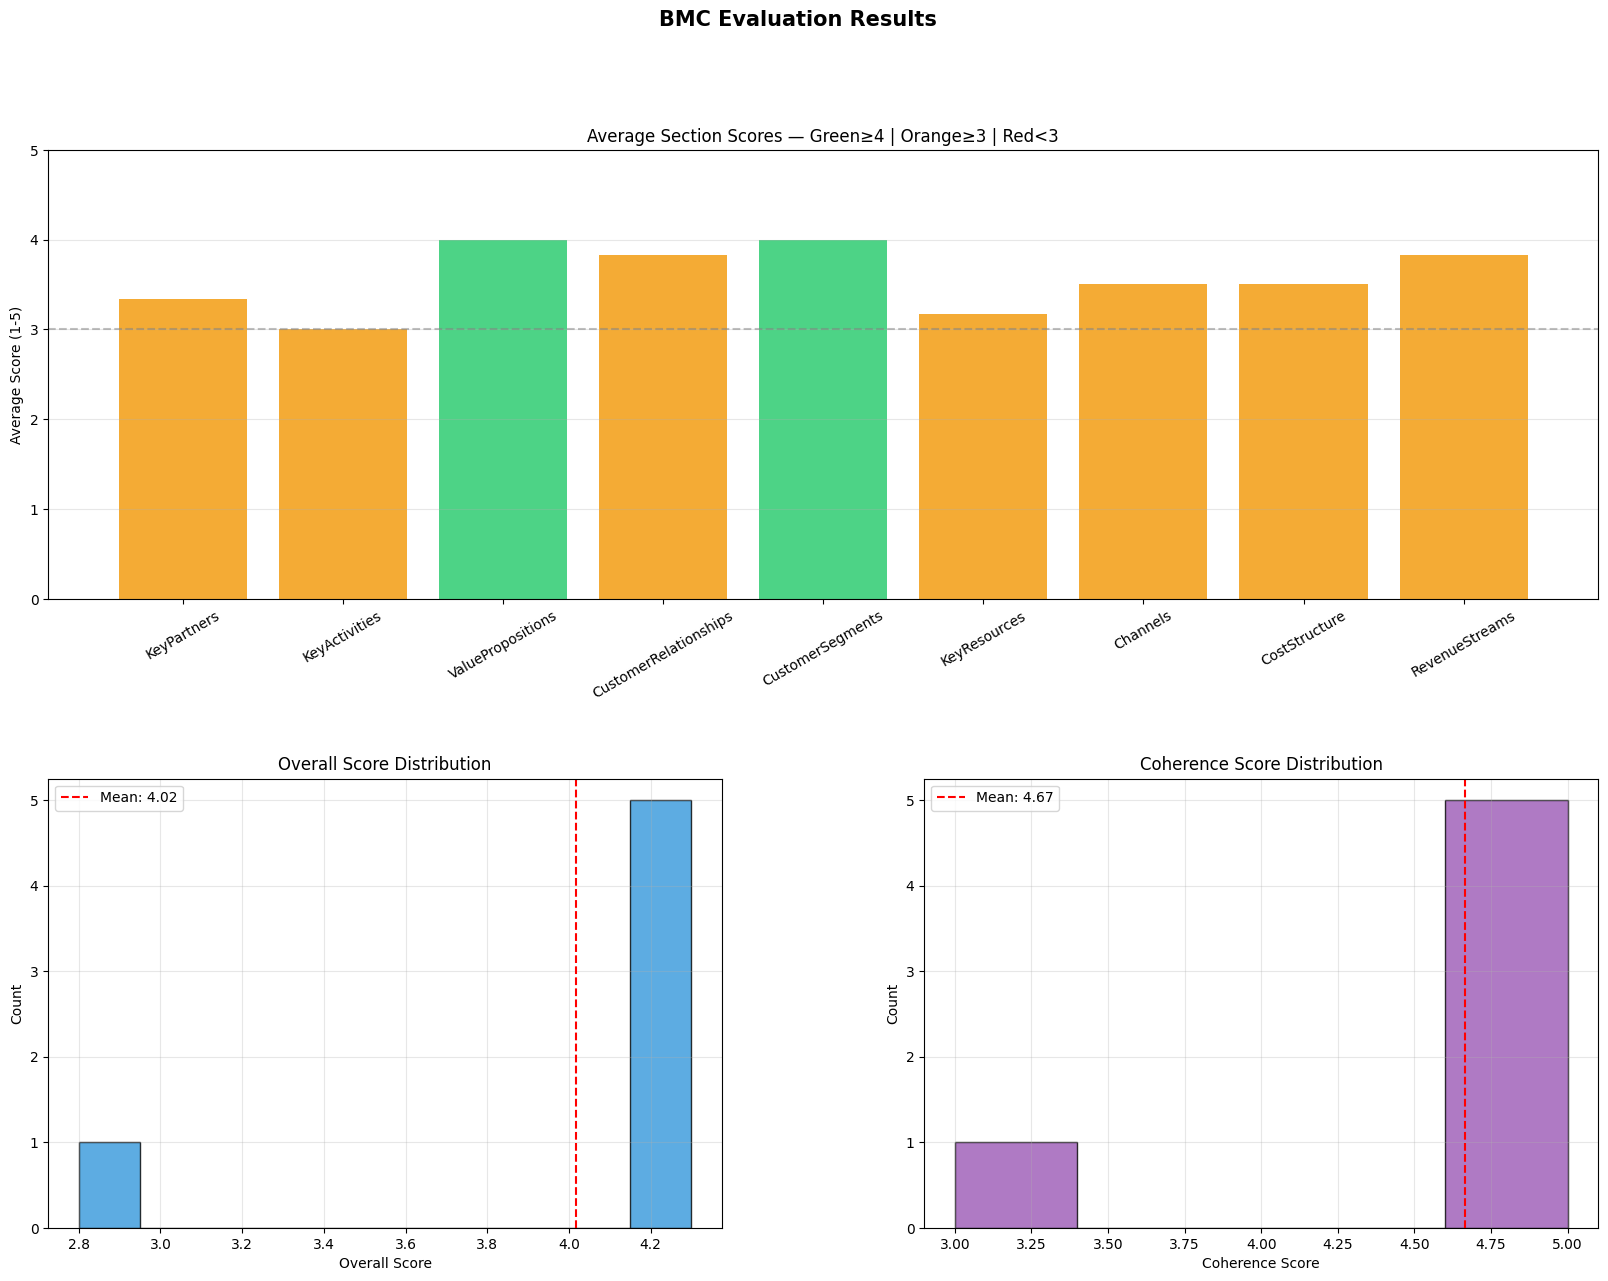


Overall: mean=4.02 min=2.8 max=4.3
Coherence: mean=4.67


In [10]:
# ============================================================
# CELL 10 — Results Visualization + Summary Report
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

successful = [e for e in all_evaluations
              if not e.get('error') and e.get('is_bmc')]

print(f"Successful evaluations : {len(successful)}")
print(f"Rejected / failed      : {len(all_evaluations) - len(successful)}")

if not successful:
    print("No successful evaluations to visualize.")
else:
    # Build summary rows
    rows = []
    for ev in successful:
        row = {
            'image':           ev['image'],
            'overall_score':   ev['overall'].get('score', 0),
            'coherence_score': ev['coherence'].get('score', 0),
            'language':        ev.get('language', 'en'),
        }
        for s in CLASS_NAMES:
            sec = ev['sections'].get(s, {})
            row[f'score_{s}'] = sec.get('score', 0)
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_DIR / 'evaluation_summary.csv', index=False)
    print(f"Summary CSV saved: {OUTPUT_DIR}/evaluation_summary.csv")

    # ── Visualization ──────────────────────────────────────
    if len(df) > 0:
        fig = plt.figure(figsize=(20, 14))
        gs  = gridspec.GridSpec(2, 2, figure=fig,
                                hspace=0.4, wspace=0.3)

        # 1. Section scores bar chart
        ax1 = fig.add_subplot(gs[0, :])
        score_cols = [f'score_{s}' for s in CLASS_NAMES]
        avg_scores = df[score_cols].mean()
        avg_scores.index = CLASS_NAMES
        colors = ['#2ecc71' if s >= 4 else '#f39c12' if s >= 3 else '#e74c3c'
                  for s in avg_scores]
        ax1.bar(CLASS_NAMES, avg_scores, color=colors, alpha=0.85)
        ax1.set_ylim(0, 5)
        ax1.set_ylabel('Average Score (1-5)')
        ax1.set_title('Average Section Scores — Green≥4 | Orange≥3 | Red<3')
        ax1.tick_params(axis='x', rotation=30)
        ax1.axhline(3, color='gray', linestyle='--', alpha=0.5)
        ax1.grid(True, alpha=0.3, axis='y')

        # 2. Overall score distribution
        ax2 = fig.add_subplot(gs[1, 0])
        ax2.hist(df['overall_score'], bins=10,
                 color='#3498db', alpha=0.8, edgecolor='black')
        ax2.axvline(df['overall_score'].mean(), color='red',
                    linestyle='--',
                    label=f"Mean: {df['overall_score'].mean():.2f}")
        ax2.set_xlabel('Overall Score')
        ax2.set_ylabel('Count')
        ax2.set_title('Overall Score Distribution')
        ax2.legend(); ax2.grid(True, alpha=0.3)

        # 3. Coherence distribution
        ax3 = fig.add_subplot(gs[1, 1])
        ax3.hist(df['coherence_score'], bins=5,
                 color='#9b59b6', alpha=0.8, edgecolor='black')
        ax3.axvline(df['coherence_score'].mean(), color='red',
                    linestyle='--',
                    label=f"Mean: {df['coherence_score'].mean():.2f}")
        ax3.set_xlabel('Coherence Score')
        ax3.set_ylabel('Count')
        ax3.set_title('Coherence Score Distribution')
        ax3.legend(); ax3.grid(True, alpha=0.3)

        plt.suptitle('BMC Evaluation Results', fontsize=15, fontweight='bold')
        plt.savefig(str(OUTPUT_DIR / 'evaluation_results.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\nOverall: mean={df['overall_score'].mean():.2f} "
              f"min={df['overall_score'].min():.1f} "
              f"max={df['overall_score'].max():.1f}")
        print(f"Coherence: mean={df['coherence_score'].mean():.2f}")

In [11]:
# ============================================================
# CELL 11 — Print Formatted Report for One Image
# ============================================================
#
# Prints a human-readable report for the first evaluated image.
# Change TARGET_IMAGE to see a specific one.

TARGET_IMAGE = None   # ← Set to image filename or leave None for first

ev = None
if TARGET_IMAGE:
    ev = next((e for e in all_evaluations
               if e['image'] == TARGET_IMAGE), None)
if ev is None and successful:
    ev = successful[0]

if ev is None:
    print("No evaluation to display.")
else:
    lang = ev.get('language', 'en')
    sep  = "=" * 60

    print(sep)
    print("BMC EVALUATION REPORT" if lang == 'en'
          else "RAPPORT D'ÉVALUATION BMC")
    print(sep)
    print(f"Image    : {ev['image']}")
    print(f"Language : {'English' if lang=='en' else 'French'}")
    print(f"Is BMC   : {'✅ YES' if ev['is_bmc'] else '❌ NO'} "
          f"({ev['bmc_confidence']:.2%})")
    print(f"Overall  : {ev['overall'].get('score', 'N/A')}/5")
    print(f"Coherence: {ev['coherence'].get('score', 'N/A')}/5")

    print(f"\n{'-'*60}")
    print("SECTION SCORES:" if lang == 'en' else "SCORES PAR SECTION:")
    for s in CLASS_NAMES:
        sec   = ev['sections'].get(s, {})
        score = sec.get('score', 0)
        bar   = '█' * score + '░' * (5 - score)
        disp  = SECTION_DISPLAY.get(s, s)
        print(f"  {disp:<30} [{bar}] {score}/5")

    print(f"\n{'-'*60}")
    print("SECTION FEEDBACK:" if lang == 'en' else "FEEDBACK PAR SECTION:")
    for s in CLASS_NAMES:
        sec  = ev['sections'].get(s, {})
        disp = SECTION_DISPLAY.get(s, s)
        print(f"\n▶ {disp} — {sec.get('score', 0)}/5 "
              f"[{sec.get('text_type','?')} via {sec.get('engine','?')}]")
        fb = sec.get('feedback', '')
        print(f"  {fb[:250]}{'...' if len(fb)>250 else ''}")

    print(f"\n{'-'*60}")
    print("COHERENCE:" if lang == 'en' else "COHÉRENCE:")
    print(ev['coherence'].get('analysis', '')[:400])

    print(f"\n{'-'*60}")
    print("SDG & ZERO-CARBON:" if lang == 'en' else "ODD & ZÉRO CARBONE:")
    print(ev['sustainability'].get('advice', '')[:400])

    print(f"\n{'-'*60}")
    print("EXECUTIVE SUMMARY:" if lang == 'en' else "RÉSUMÉ EXÉCUTIF:")
    print(ev['overall'].get('summary', '')[:400])
    print(sep)

BMC EVALUATION REPORT
Image    : Zara_Business_Model_Canvas_8f5824dc20.png
Language : English
Is BMC   : ✅ YES (99.50%)
Overall  : 4.3/5
Coherence: 5/5

------------------------------------------------------------
SECTION SCORES:
  Key Partners                   [████░] 4/5
  Key Activities                 [███░░] 3/5
  Value Propositions             [████░] 4/5
  Customer Relationships         [████░] 4/5
  Customer Segments              [████░] 4/5
  Key Resources                  [████░] 4/5
  Channels                       [████░] 4/5
  Cost Structure                 [████░] 4/5
  Revenue Streams                [████░] 4/5

------------------------------------------------------------
SECTION FEEDBACK:

▶ Key Partners — 4/5 [typed via easyocr]
  Here is my evaluation:

**Score: 4/5**

The "Key Partners" section appears to list various partners that support the fabric manufacturer's operations. The inclusion of specific companies like "Fabric supply", "Logistics provider", and "Techn

In [12]:
# ============================================================
# CELL 12 — Export Package
# ============================================================

export_dir = WORK_DIR / "final_output"
if export_dir.exists():
    shutil.rmtree(export_dir)
export_dir.mkdir()

# Copy outputs
shutil.copytree(JSON_DIR, export_dir / "json")
if (OUTPUT_DIR / 'evaluation_summary.csv').exists():
    shutil.copy(OUTPUT_DIR / 'evaluation_summary.csv',
                export_dir / 'evaluation_summary.csv')
if (OUTPUT_DIR / 'evaluation_results.png').exists():
    shutil.copy(OUTPUT_DIR / 'evaluation_results.png',
                export_dir / 'evaluation_results.png')

# Copy Llama adapter for reuse
if LLAMA_ADAPTER_PATH.exists():
    shutil.copytree(LLAMA_ADAPTER_PATH, export_dir / "llama_bmc_adapter")

shutil.make_archive(str(WORK_DIR / 'final_output'), 'zip', str(export_dir))

print("=== EXPORT COMPLETE ===")
print(f"ZIP: {WORK_DIR}/final_output.zip")
print(f"\nContents:")
print(f"  json/                  ← one JSON per evaluated BMC")
print(f"  evaluation_summary.csv ← all scores in one table")
print(f"  evaluation_results.png ← visualization charts")
print(f"  llama_bmc_adapter/     ← fine-tuned adapter (reuse in testing NB)")
print(f"\nUpload llama_bmc_adapter/ to Kaggle dataset for testing notebook.")

=== EXPORT COMPLETE ===
ZIP: /kaggle/working/final_output.zip

Contents:
  json/                  ← one JSON per evaluated BMC
  evaluation_summary.csv ← all scores in one table
  evaluation_results.png ← visualization charts
  llama_bmc_adapter/     ← fine-tuned adapter (reuse in testing NB)

Upload llama_bmc_adapter/ to Kaggle dataset for testing notebook.


In [13]:
!zip -r folder.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 70%)
  adding: kaggle/working/book_chunks.csv (deflated 72%)
  adding: kaggle/working/final_output.zip (stored 0%)
  adding: kaggle/working/final_evaluations/ (stored 0%)
  adding: kaggle/working/final_evaluations/evaluation_results.png (deflated 22%)
  adding: kaggle/working/final_evaluations/json/ (stored 0%)
  adding: kaggle/working/final_evaluations/json/675083_cc54po_zqsmjwysasb7kmtlwi_evaluation.json (deflated 67%)
  adding: kaggle/working/final_evaluations/json/neg_0182_evaluation.json (deflated 33%)
  adding: kaggle/working/final_evaluations/json/instagram-business-model-canvas-english_evaluation.json (deflated 66%)
  adding: kaggle/working/final_evaluations/json/f1929a89-3445-44b5-acec-a24ff5c2b862_evaluation.json (deflated 30%)
  adding: kaggle/working/final_evaluations/json/example-business-model-canvas

In [14]:
from IPython.display import FileLink
FileLink(r'folder.zip')

/kaggle/working/folder.zip